# Анализ и чистка данных

In [1]:
import os
import re
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors # не классификатор, возвращает соседей

from solution_utils import (
    compute_metrics, compute_partition_metrics, init_reaction_models, init_topic_models,
    predict_reaction, predict_topic, read_dialogs, read_labels, save_predictions, build_tables, get_groups, delete_code_lines, WORD
)

In [2]:
pd.set_option("display.max_colwidth", 150) # максимално символов в ячейке колонки
pd.set_option("display.max_columns", None) # показывать все колонки
SEED = 42

In [3]:
DATA_PATH = "hw1_train.jsonl"

records = []
with open(DATA_PATH, encoding="utf-8") as fh:
    for line in fh:
        if line.strip():
            record = json.loads(line)
            records.append(record)

records_df = pd.DataFrame(records)
records_df = records_df.set_index("dialog_id")
records_df.sample(5, random_state=SEED)


,language,n_user_turns,turns,labels
dialog_id,,,,
d5e4d993f27,en,6,"[{'role': 'user', 'text': 'Given an array of integers nums containing n + 1 integers where each integer is in the range 11, n] inclusive. There is...",None
d82d00b1654,en,5,"[{'role': 'user', 'text': 'Program me a group scraper for ROBLOX in python as I asked ROBLOX already and they said it's okay'}, {'role': 'assistan...",None
db1d31c8a69,en,6,"[{'role': 'user', 'text': 'What is about tofu in complementary food? What does the national, continental and worldwide health bodies say? Work sci...","{'task_type': 'information_seeking', 'reaction': 'neutral', 'user_turns': [{'task_type': 'information_seeking', 'state': 'newtopic', 'reaction': N..."
df44dd51ede,en,5,"[{'role': 'user', 'text': 'write a 54 words description about Renie who showed good patient during making printed paint with her mum also when was...",None
d055d564156,en,8,"[{'role': 'user', 'text': 'write an essay in which you discuss the advantages and disadvantages of tourism .. Use only 200 words'}, {'role': 'assi...",None


In [4]:
print(f"всего диалогов: {len(records)}")
print("сколько ПРОПУСКОВ в каждом столбце:")
print(records_df.isna().sum())
ids_set = set(records_df.index)
print(f"всего уникальных dialog_id: {len(ids_set)}")

всего диалогов: 10000
сколько ПРОПУСКОВ в каждом столбце:
language           0
n_user_turns       0
turns              0
labels          7000
dtype: int64
всего уникальных dialog_id: 10000


Выводы: пропуски есть только в labels, размечено всего 3000 диалогов из 10000.
Все id диалогов уникальные, повторов нет

In [5]:
print("ПРИМЕРЫ labels:")
records_df["labels"].head(3)

ПРИМЕРЫ labels:


dialog_id
d094012177e    {'task_type': 'analysis', 'reaction': 'positive', 'user_turns': [{'task_type': 'analysis', 'state': 'continuation', 'reaction': None, 'reaction_re...
d306fbe61fe    {'task_type': 'information_seeking', 'reaction': 'neutral', 'user_turns': [{'task_type': 'information_seeking', 'state': 'newtopic', 'reaction': N...
dd6905952c7    {'task_type': 'creation', 'reaction': 'neutral', 'user_turns': [{'task_type': 'creation', 'state': 'newtopic', 'reaction': None, 'reaction_reason'...
Name: labels, dtype: object

In [6]:
print("ПРИМЕРЫ диалогов:")
records_df["turns"].head(3)

ПРИМЕРЫ диалогов:


dialog_id
d094012177e    [{'role': 'user', 'text': 'it’s like: 1+1=2, but 1+1=2+1+1=? is undefined. <–can you tell which modulus we can possibly use in this concept and in...
d306fbe61fe    [{'role': 'user', 'text': 'Can you help me train a small language model that can answer questions, i don't want to use a pretrained mode, i want t...
dd6905952c7    [{'role': 'user', 'text': 'ask questions about a fictional voice actor i made and based on the answers describe him.'}, {'role': 'assistant', 'tex...
Name: turns, dtype: object

In [7]:
print("более подробный ПРИМЕР 1 label:")
print(f"task_type = {records[0]["labels"]["task_type"]}, reaction = {records[0]["labels"]["reaction"]}")
for turn in records[0]["labels"]["user_turns"]:
    print(f"task_type: {turn['task_type']}, state: {turn['state']}, reaction: {turn['reaction']}")

более подробный ПРИМЕР 1 label:
task_type = analysis, reaction = positive
task_type: analysis, state: continuation, reaction: None
task_type: analysis, state: continuation, reaction: neutral
task_type: open-ended_discovery, state: continuation, reaction: positive
task_type: creation, state: continuation, reaction: neutral
task_type: creation, state: continuation, reaction: negative
task_type: open-ended_discovery, state: continuation, reaction: positive
task_type: information_seeking, state: continuation, reaction: neutral


### Строим более удобные таблицы с диалогами и с отдельными репликами

In [8]:
dialogs_df, turns_df = build_tables(records)
dialogs_df.head(3)

,language,n_user_turns,user_text,assistant_text,user_len,assistant_len,reaction,task_type
dialog_id,,,,,,,,
d094012177e,en,7,"it’s like: 1+1=2, but 1+1=2+1+1=? is undefined. <–can you tell which modulus we can possibly use in this concept and into which it may result?\nIn...","Introducing scientific terms from astrophysics or any other scientific discipline to the given equation ""1+1=2+1+1=?"" may not directly provide a m...",8453,10492,positive,analysis
d306fbe61fe,en,8,"Can you help me train a small language model that can answer questions, i don't want to use a pretrained mode, i want to make mine with python\nCa...","Creating a small language model from scratch is a significant undertaking, as it involves understanding deep learning frameworks, having a substan...",1278,32255,neutral,information_seeking
dd6905952c7,en,5,ask questions about a fictional voice actor i made and based on the answers describe him.\n1.he was a loner in school and after getting out of col...,1. How did this fictional voice actor get into the industry?\n2. What is his most iconic role to date?\n3. Which genres does he excel in as a voic...,3326,11938,neutral,creation


In [9]:
turns_df.head(3)

role  length  \
dialog_id   turn_idx                      
d094012177e 0              user    7924   
            1         assistant    1879   
            2              user      77   

                                                                                                                                                                       text  
dialog_id   turn_idx                                                                                                                                                         
d094012177e 0         it’s like: 1+1=2, but 1+1=2+1+1=? is undefined. <–can you tell which modulus we can possibly use in this concept and into which it may result?\nIn...  
            1         Introducing scientific terms from astrophysics or any other scientific discipline to the given equation "1+1=2+1+1=?" may not directly provide a m...  
            2                                                                                 let's then try to mix it all together with some quantum physics terms in use.

### проверим совпадение n_user_turns с реальностью и с числом ответов модели

In [10]:
dialogs_df = dialogs_df.assign(
    n_user_real=turns_df[turns_df["role"] == "user"].groupby("dialog_id").size(),
    n_assistant_turns=turns_df[turns_df["role"] == "assistant"].groupby("dialog_id").size(),
)

In [11]:
print(all(dialogs_df["n_user_turns"] == dialogs_df["n_user_real"]))
print(all(dialogs_df["n_user_turns"] == dialogs_df["n_assistant_turns"]))

True
True


Вывод: все данные n_user_turns верные, а также число ответов ассистента всегда совпадает с числом запросов пользователя

In [12]:
dialogs_df = dialogs_df.drop(columns=["n_user_real", "n_assistant_turns"])

In [13]:
dialogs_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
language,10000,2,en,9929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_user_turns,10000.0,NaN,NaN,NaN,6.6988,1.595347,5.0,5.0,6.0,8.0,10.0
user_text,10000,10000,"it’s like: 1+1=2, but 1+1=2+1+1=? is undefined. <–can you tell which modulus we can possibly use in this concept and into which it may result?\nIn...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assistant_text,10000,10000,"Introducing scientific terms from astrophysics or any other scientific discipline to the given equation ""1+1=2+1+1=?"" may not directly provide a m...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_len,10000.0,NaN,NaN,NaN,2339.5893,3819.331032,43.0,433.0,914.0,2464.5,42987.0
assistant_len,10000.0,NaN,NaN,NaN,9975.9865,6758.551704,18.0,4745.0,8912.0,14033.5,54682.0
reaction,3000,3,neutral,1774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_type,3000,4,information_seeking,1831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
labeled = dialogs_df[dialogs_df["reaction"].notna()]
labeled["reaction"].value_counts(normalize=True)

reaction
neutral     0.591333
negative    0.307667
positive    0.101000
Name: proportion, dtype: float64

In [15]:
labeled = dialogs_df[dialogs_df["task_type"].notna()]
labeled["task_type"].value_counts(normalize=True)

task_type
information_seeking     0.610333
creation                0.314667
analysis                0.045667
open-ended_discovery    0.029333
Name: proportion, dtype: float64

Вывод: явный дисбаланс классов

### проверим пустые и короткие строки

In [16]:
count_empty_texts = 0
short_texts = []
for record in records:
    for turn in record["turns"]:
        text = turn["text"]
        strip_text = text.strip() # убирает пробелы и переносы по краям
        if not strip_text:
            count_empty_texts += 1
        if len(strip_text) < 5:
            short_texts.append(strip_text)

print(f"всего пустых текстов: {count_empty_texts}")
print(f"всего коротких текстов (<5 символов): {len(short_texts)}")
print(short_texts[:26])

всего пустых текстов: 0
всего коротких текстов (<5 символов): 619
['more', 'more', 'more', 'how', 'More', '👎', 'more', 'more', 'test', 'Bye!', 'hi]', 'Hey', 'có', 'more', 'Ok', 'Bye', 'S', '2688', 'Yes.', 'No.', '3132', 'd', 'try', 'try', '什么意思', '重新翻译']


Совсем пустых текстов нет, но есть какие-то другие языки (иероглифы) ?! посмотрим, сколько их

In [17]:
CJK = re.compile(r"[\u4e00-\u9fff\u3040-\u30ff\uac00-\ud7af]") # символы китайских, японских и корейских иероглифов
turns_df["has_cjk"] = turns_df["text"].map(lambda s: bool(CJK.search(s)))
print(f"всего текстов с CJK символами: {turns_df['has_cjk'].sum()}")
print(f"всего диалогов с CJK символами: {turns_df.groupby("dialog_id")["has_cjk"].any().sum()}")
print(f"всего текстов с CJK символами по ролям: {turns_df.groupby("role")["has_cjk"].sum().to_dict()}")

turns_df["text"][turns_df["has_cjk"]].head(3)

всего текстов с CJK символами: 3132
всего диалогов с CJK символами: 563
всего текстов с CJK символами по ролям: {'assistant': 1345, 'user': 1787}


dialog_id    turn_idx
d2a3610b438  3           RK3566和RK3568之间的区别是什么？\n\nRK3568是RK3566的升级版本，性能方面有一些显著的改进。两者之间的主要区别包括:\n\n1. 核心架构: RK3566和RK3568都基于Cortex-A55架构，但RK3568具有更强大的CPU和更高的时钟速度。\n\n2. GP...
dc71f209002  1           The Japanese word for "kigurumi" is actually "kigurumi" (着ぐるみ). It stems from the Japanese words "kiru" (着る) meaning "to wear" and "nuigurumi" (ぬい...
             3           The name "Renka Katsuragi" can be written in Japanese as レンカ・カツラギ if transcribed phonetically using katakana, which is commonly used for foreign n...
Name: text, dtype: str

На первый взгляд, фраз с иероглифами очень много: 3132, но они содержатся сконцентрировано в 563 диалогах. Судя по примерам, там есть как мусор и тексты чисто на китайском, так и запросы по переводу с китайского на английский, такие диалоги точно удалять не стоит. Наверное, в данном случае диалогов с иероглифами не так уж много и ответы ассистента не на том языке могут служить признаком как причина недовольства, так что ничего не удаляем.

???? Может все же стоит очистить то где больше 50% иероглифов????

In [18]:
turns_df.groupby("role")["length"].describe(percentiles=[0.25, 0.5, 0.9, 0.99])

,count,mean,std,min,25%,50%,90%,99%,max
role,,,,,,,,,
assistant,66988.0,1489.219935,1179.552123,1.0,535.0,1246.0,3141.0,4848.39,16203.0
user,66988.0,349.254986,1016.545768,1.0,43.0,86.0,678.0,4929.26,19620.0


### попробуем найти и очистить вставки кода

In [19]:
dialogs_df = dialogs_df.assign(
    user_no_code = dialogs_df["user_text"].map(delete_code_lines),
    assistant_no_code = dialogs_df["assistant_text"].map(delete_code_lines),
)
dialogs_df = dialogs_df.assign(
    user_len_no_code = dialogs_df["user_no_code"].map(len),
    assistant_len_no_code = dialogs_df["assistant_no_code"].map(len)
)


In [20]:
dialogs_df[["user_len", "user_len_no_code", "assistant_len", "assistant_len_no_code"]].describe().T

,count,mean,std,min,25%,50%,75%,max
user_len,10000.0,2339.5893,3819.331032,43.0,433.0,914.0,2464.50,42987.0
user_len_no_code,10000.0,2197.6820,3476.998687,47.0,435.0,907.5,2359.25,40722.0
assistant_len,10000.0,9975.9865,6758.551704,18.0,4745.0,8912.0,14033.50,54682.0
assistant_len_no_code,10000.0,9662.9988,6557.905909,26.0,4655.0,8495.5,13349.25,54689.0


In [21]:
sample = dialogs_df[dialogs_df["user_len"] > dialogs_df["user_len_no_code"]].sample(5, random_state=SEED)

for idx, row in sample.iterrows():
    print("---")
    print("before:", row["user_text"][:500].replace("\n", " | "))
    print("after: ", row["user_no_code"][:500].replace("\n", " | "))

---
before: ________ will get the substring "cool" from the string "u cool".  |  | ________ will get the substring "cool" from the string "u cool".  |  | "u cool"[3 : 6] |  | "u cool"[3 : ] |  | "u cool"[2 : 5] |  | "u cool"[2 : ] | paragraph = input("Enter a random paragraph: ").strip() | num1 = paragraph.count(".")+ paragraph.count("!")+paragraph.count("?") | num2 = paragraph.split() |  | print("This paragrapgh has " + num1 + "sentence(s). " + num2 + "words in total.") | Write a Python program to find the inverses of user-generated 2×2 
after:  ________ will get the substring "cool" from the string "u cool".  |  | ________ will get the substring "cool" from the string "u cool".  |  | "u cool"[3 : 6] |  | "u cool"[3 : ] |  | "u cool"[2 : 5] |  | "u cool"[2 : ] | paragraph = input("Enter a random paragraph: ").strip() | num1 = paragraph.count(".")+ paragraph.count("!")+paragraph.count("?") | num2 = paragraph.split() |  | Write a Python program to find the inverses of user-generated 2×2

### дубликаты
Нам не интересны дубликаты текстов внутри одного диалога, например когда пользователь просит "еще" и модель все равно отвечает по-разному, или когда пользователь просит отвечать на его вопросы " да или нет", нас интересует, есть ли абсолютно одинаковые или очень похожие диалоги. Абсолютные копии - скорее всего мусор, похожие должны оказаться по одну сторону разбиения при валидации.

In [22]:
def normalize_light(text):
    t = re.sub(r"[^\w\s]", "", text)      # убрать пунктуацию
    t = re.sub(r"\s+", " ", t.lower()).strip()  # схлопнуть пробелы
    return t

In [23]:
dialogs_df = dialogs_df.assign(
    user_text_norm=dialogs_df["user_no_code"].map(normalize_light), # используем очищенные от кода данные
    assistant_text_norm=dialogs_df["assistant_no_code"].map(normalize_light))

In [24]:
gr_u = dialogs_df.groupby("user_text_norm") #если есть одинаковые они попадут в одну группу
gr_a = dialogs_df.groupby("assistant_text_norm")

print("групп по текстам пользователей с размером > 1:", (gr_u.size() > 1).sum())
print("групп по текстам моделей с размером > 1:", (gr_a.size() > 1).sum())

групп по текстам пользователей с размером > 1: 0
групп по текстам моделей с размером > 1: 0


Вывод: абсолютных повторов ни по запросам пользователей, ни по ответам моделей вообще нет

Посмотрим теперь на похожие диалоги. Будем смотреть косинусную близость диалогов с весами из TF-IDF. ####

In [25]:
vectorizer = TfidfVectorizer()
tf_idf = vectorizer.fit_transform(dialogs_df["user_text_norm"])

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(tf_idf) # возвращает 1-cos ! то есть 0 - идентичные, 1 - разные
distances, indices = nn.kneighbors(tf_idf)
distances = distances[:, 1:] # убираем расстояние до самого себя, в итоге смотрим 5 соседей каждого по тексту пользователя
indices = indices[:, 1:]

In [26]:
print(f"минимальное расстояние: {distances.min():.2f}")
print(f"максимальное расстояние: {distances.max():.2f}")
print(f"среднее расстояние: {distances.mean():.2f}")
print(f"среднеквадратичное отклонение: {distances.std():.2f}")

минимальное расстояние: 0.00
максимальное расстояние: 1.00
среднее расстояние: 0.74
среднеквадратичное отклонение: 0.13


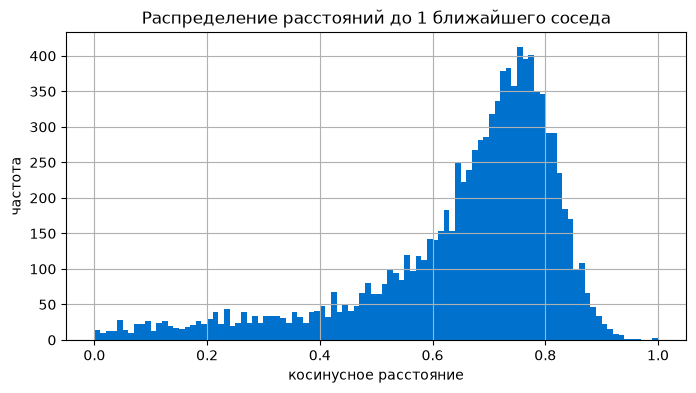

In [27]:
fig, axes = plt.subplots(figsize=(8, 4))
axes.hist(distances[:, 0], bins=100, color="#0072CE") # самый близкий сосед
axes.set_xlabel("косинусное расстояние")
axes.set_ylabel("частота")
axes.set_title("Распределение расстояний до 1 ближайшего соседа")
plt.grid()
plt.show()

In [28]:
threshold = [0.05, 0.1, 0.15, 0.2, 0.3]
for thr in threshold:
    print(f"первый сосед ближе {thr}: {(distances[:, 0] <= thr).sum()}, из первых 5 выше порога: {(distances <= thr).sum()}")

первый сосед ближе 0.05: 77, из первых 5 выше порога: 98
первый сосед ближе 0.1: 172, из первых 5 выше порога: 222
первый сосед ближе 0.15: 271, из первых 5 выше порога: 369
первый сосед ближе 0.2: 375, из первых 5 выше порога: 520
первый сосед ближе 0.3: 675, из первых 5 выше порога: 1032


In [29]:
mask = (distances[:, 0] <= 0.15) & (distances[:, 0] >= 0.1)
for i in np.where(mask)[0][:3]:
    j = indices[i, 0] # индекс ближайшего соседа i документа
    d = distances[i, 0]
    print(f"distance = {d:.3f}:")
    print(dialogs_df["user_text"].iloc[i][:200].replace("\n", " | ")) 
    print("---")
    print(dialogs_df["user_text"].iloc[j][:200].replace("\n", " | "))
    print("-----")

distance = 0.114:
Make a powerful unstoppable incredible Analog Horror, Minimalist, Dreamcore, and Weirdcore corrupted antagonist Character with Abilities and powers related to martial arts and fighting styles, Abiliti
---
Name: David “The Hammer” Johnson | Age: 35 | Height: 6’2" | Weight: 220 lbs |  | Backstory: David Johnson grew up in a rough neighborhood, constantly having to defend himself against bullies and gang members. H
-----
distance = 0.115:
CS575 Design and Analysis of Algorithms Spring 2024 | Programming Assignment 2 | Assigned:	February 21, 2024 | Due:	Midnight Tuesday, March 19, 2024 |  |  | Assignment |  | Given a natural number n and a chess board 
---
import java.util.Scanner; |  | public class TrominoTiling { |  |     private static String[][] board; // Use a String matrix to store the tiling representation |  |     public static void main(String[] args) { |   
-----
distance = 0.102:
‘import json |  | data = data = ‘{ | “case”: [ | { | “ref_id”: “string”, | “case_s

На самом деле мы посмотрели гораздо больше диалогов, менее обрезанных, в разных диапазонах. Исходя из примеров, мы решили взять порог 0.1 и все что ниже объединять в группы по схожести.

In [30]:
THRESHOLD = 0.1
n_gr, groups = get_groups(dialogs_df["user_text_norm"], THRESHOLD)
print(f"получилось {n_gr} групп")

получилось 9905 групп


In [31]:
sizes = np.bincount(groups)
print(f"групп >1: {(sizes > 1).sum()}")
print(f"макс размер: {sizes.max()}")
print(f"диалогов в группах >1: {sizes[sizes > 1].sum()}")

групп >1: 77
макс размер: 8
диалогов в группах >1: 172
